In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())  # False is fine — CPU training is ok

2.12.0+cpu
False


In [2]:
import torch
import numpy as np

# numpy array vs pytorch tensor
np_array = np.array([[1.0, 2.0], [3.0, 4.0]])
tensor   = torch.tensor([[1.0, 2.0], [3.0, 4.0]])

print(type(np_array))  # numpy.ndarray
print(type(tensor))    # torch.Tensor
print(tensor.shape)    # torch.Size([2, 2])
print(tensor.dtype)    # torch.float32

# convert between them
back_to_numpy = tensor.numpy()
back_to_tensor = torch.from_numpy(np_array)
print(back_to_numpy)
print(back_to_tensor)

<class 'numpy.ndarray'>
<class 'torch.Tensor'>
torch.Size([2, 2])
torch.float32
[[1. 2.]
 [3. 4.]]
tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64)


In [3]:
# requires_grad=True tells PyTorch to track this tensor
x = torch.tensor(3.0, requires_grad=True)

# compute something
y = x ** 2 + 2*x + 1  # y = (x+1)^2

# backward computes gradients automatically
y.backward()

# dy/dx = 2x + 2 = 2(3) + 2 = 8
print(f"x = {x}")
print(f"y = {y}")
print(f"dy/dx = {x.grad}")  # should be 8.0

x = 3.0
y = 16.0
dy/dx = 8.0


Epoch    0 → Loss: 0.7215
Epoch  200 → Loss: 0.1107
Epoch  400 → Loss: 0.0271
Epoch  600 → Loss: 0.0127
Epoch  800 → Loss: 0.0075
Epoch 1000 → Loss: 0.0050
Epoch 1200 → Loss: 0.0036
Epoch 1400 → Loss: 0.0027
Epoch 1600 → Loss: 0.0021
Epoch 1800 → Loss: 0.0017

Final predictions:
[[0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]]


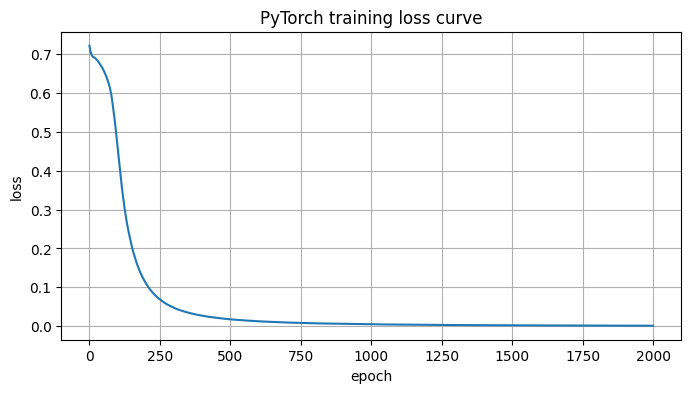


Final predictions:
[[0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]]

Actual:
[[0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]]


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# XOR dataset
X = torch.tensor([[0, 0, 1],
                  [0, 1, 1],
                  [1, 0, 1],
                  [1, 1, 1]], dtype=torch.float32)

y = torch.tensor([[0, 1],
                  [1, 0],
                  [1, 0],
                  [0, 1]], dtype=torch.float32)

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(3, 4)
        self.layer2 = nn.Linear(4, 2)
        self.relu    = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.sigmoid(self.layer2(x))
        return x

torch.manual_seed(42)  # for reproducibility
model     = NeuralNetwork()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

losses = []

for epoch in range(2000):
    output = model(X)
    loss   = criterion(output, y)
    losses.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 200 == 0:
        print(f"Epoch {epoch:4d} → Loss: {loss.item():.4f}")

with torch.no_grad():
    predictions = model(X)
    print("\nFinal predictions:")
    print(predictions.numpy().round(2))

# plot
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('PyTorch training loss curve')
plt.grid(True)
plt.show()

# predictions
with torch.no_grad():
    predictions = model(X)
    print("\nFinal predictions:")
    print(predictions.numpy().round(2))
    print("\nActual:")
    print(y.numpy())

In [4]:
from torch.utils.data import Dataset, DataLoader

class XORDataset(Dataset):
    def __init__(self):
        self.X = torch.tensor([[0, 0, 1],
                               [0, 1, 1],
                               [1, 0, 1],
                               [1, 1, 1]], dtype=torch.float32)
        self.y = torch.tensor([[0, 1],
                               [1, 0],
                               [1, 0],
                               [0, 1]], dtype=torch.float32)

    def __len__(self):
        return len(self.X)          # total number of samples

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]  # one sample at a time

# create dataloader — batches data automatically
dataset    = XORDataset()
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

# training with dataloader
torch.manual_seed(42)
model     = NeuralNetwork()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

losses = []

for epoch in range(2000):
    epoch_loss = 0
    for batch_X, batch_y in dataloader:  # iterate over batches
        output = model(batch_X)
        loss   = criterion(output, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    losses.append(epoch_loss)

    if epoch % 200 == 0:
        print(f"Epoch {epoch:4d} → Loss: {epoch_loss:.4f}")

# final predictions
with torch.no_grad():
    predictions = model(X)
    print("\nFinal predictions:")
    print(predictions.numpy().round(2))

Epoch    0 → Loss: 1.4674
Epoch  200 → Loss: 0.8742
Epoch  400 → Loss: 0.0426
Epoch  600 → Loss: 0.0128
Epoch  800 → Loss: 0.0061
Epoch 1000 → Loss: 0.0034
Epoch 1200 → Loss: 0.0022
Epoch 1400 → Loss: 0.0015
Epoch 1600 → Loss: 0.0010
Epoch 1800 → Loss: 0.0007

Final predictions:
[[0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]]
